In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F #activation functions
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

In [53]:
transform = transforms.ToTensor()

#converts PIL images to Pytorch Tensor with properties:
#1. convert image to tensor format
#2. scale pixels from [0,255] to [0.0,1.0]
#3. changes shapes from (h,w) to (c,h,w)


In [54]:
train_data = datasets.MNIST(root='../Data',train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='../Data',train=False, download=True, transform=transform)

In [55]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [56]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [57]:
np.random.randint(0,59999,1)[0]

np.int64(3238)

In [58]:
image, label = train_data[np.random.randint(0,59999,1)[0]]

In [59]:
image.shape

torch.Size([1, 28, 28])

The number in the image is : 2


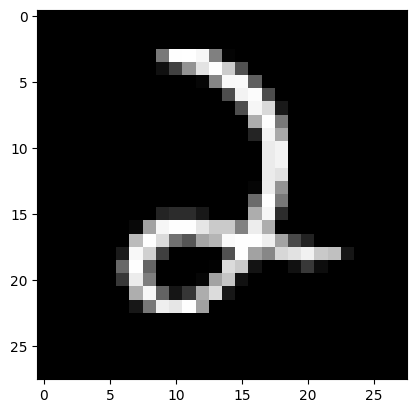

In [60]:
image, label = train_data[np.random.randint(0,59999,1)[0]]
print(f"The number in the image is : {label}")
plt.imshow(image.reshape((28,28)),cmap='gray')

In [61]:
28*28

784

In [62]:
#784-->>120-->>84-->>10

layer1(input-->>hidden1)

weights: 784 inputs * 120 neurons = 94080
biases: 120 neuron = 120
total paramters : 120+94080 = 94200


layer2(hidden1-->>hidden2):
weights: 120*84 = 10080
biases: 84
total = 10164

layers3(hidden2-->>output):
weights = 84*10=840
biases: 10
total= 850


grand total = 94200+10164+850 = 105214 parameters

In [63]:
#Data Loader configuration
torch.manual_seed(101)
train_loader = DataLoader(train_data,batch_size=100, shuffle=True)
test_loader = DataLoader(test_data,shuffle=False, batch_size=500)

In [64]:
class MultiLayerPercpetronModel(nn.Module):
  def __init__(self, in_size=784, out_size=10, layers=[120,84]):
    super().__init__()
    self.ffn1 = nn.Linear(in_size,layers[0])
    self.ffn2 = nn.Linear(layers[0],layers[1])
    self.ffn3 = nn.Linear(layers[1],out_size)

  def forward(self,X):
    X = F.relu(self.ffn1(X))
    X = F.relu(self.ffn2(X))
    X = self.ffn3(X)

    return  X #converts output into log probabilities


#log_softmax is used with nn.NLLLoss

In [65]:
torch.manual_seed(101)
model = MultiLayerPercpetronModel()
model

MultiLayerPercpetronModel(
  (ffn1): Linear(in_features=784, out_features=120, bias=True)
  (ffn2): Linear(in_features=120, out_features=84, bias=True)
  (ffn3): Linear(in_features=84, out_features=10, bias=True)
)

In [66]:
[p.numel() for p in model.parameters() if p.requires_grad == True]

[94080, 120, 10080, 84, 840, 10]

In [67]:
criterion = nn.CrossEntropyLoss() #combines log_softmax + nn.NLLLoss
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01) #for adam, lr = .001 to .0003

In [68]:
for images, labels in train_loader:
  print(f"batch shape is {images.size()}")
  break

batch shape is torch.Size([100, 1, 28, 28])


In [69]:
images.view(100,-1).size()

torch.Size([100, 784])

In [70]:
#train the model

import time

start_time = time.time()

epochs = 20
train_losses = []
test_losses = []

train_correct = []
test_correct = []

for i in range(epochs):

  trn_corr = 0 #track correct predictions
  tst_corr = 0

  #run the training batches
  for b, (X_train, y_train) in enumerate(train_loader):
    b = b + 1

    #apply the model
    y_pred = model(X_train.view(100,-1)) #Flattenning of training images
    loss = criterion(y_pred, y_train)

    #tally the number of correct predictions
    predicted = torch.max(y_pred.data,1)[1] #get class indices
    batch_corr = (predicted==y_train).sum() #count correct predictions
    trn_corr += batch_corr

    #update paramters
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #print intermediate result
    if b%200 == 0:
      print(f"Epoch: {i:2} batch: {b:2} [{100*b:6}/60000] loss: {loss.item() : 10.8f} accuracy: {trn_corr.item()*100/(100*b):7.3f}%")

  #update train loss and accuracy for the epoch in question
  train_losses.append(loss)
  train_correct.append(trn_corr)

  #Run the testing batches
  with torch.no_grad(): #disable gradient computation
    for b, (X_test,y_test) in enumerate(test_loader):

      y_val = model(X_test.view(500,-1))

      predicted = torch.max(y_val.data,1)[1]
      tst_corr += (predicted==y_test).sum()

  #update the test loss and accuracy for the epoch
  loss = criterion(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)

print(f"\n\nDuration: {time.time() - start_time : .0f} seconds")

Epoch:  0 batch: 200 [ 20000/6000] loss:  0.43250751 accuracy:  88.285%
Epoch:  0 batch: 400 [ 40000/6000] loss:  0.27643117 accuracy:  91.360%
Epoch:  0 batch: 600 [ 60000/6000] loss:  0.14316529 accuracy:  92.605%
Epoch:  1 batch: 200 [ 20000/6000] loss:  0.11210793 accuracy:  96.335%
Epoch:  1 batch: 400 [ 40000/6000] loss:  0.08135799 accuracy:  96.302%
Epoch:  1 batch: 600 [ 60000/6000] loss:  0.13131469 accuracy:  96.330%
Epoch:  2 batch: 200 [ 20000/6000] loss:  0.16932911 accuracy:  96.880%
Epoch:  2 batch: 400 [ 40000/6000] loss:  0.17162281 accuracy:  96.855%
Epoch:  2 batch: 600 [ 60000/6000] loss:  0.11277995 accuracy:  96.793%
Epoch:  3 batch: 200 [ 20000/6000] loss:  0.17990495 accuracy:  97.380%
Epoch:  3 batch: 400 [ 40000/6000] loss:  0.04310865 accuracy:  97.347%
Epoch:  3 batch: 600 [ 60000/6000] loss:  0.08472452 accuracy:  97.245%
Epoch:  4 batch: 200 [ 20000/6000] loss:  0.02934994 accuracy:  97.505%
Epoch:  4 batch: 400 [ 40000/6000] loss:  0.07794271 accuracy:  

In [71]:
print(test_correct)

[tensor(9559), tensor(9610), tensor(9564), tensor(9643), tensor(9613), tensor(9661), tensor(9689), tensor(9661), tensor(9649), tensor(9679), tensor(9690), tensor(9703), tensor(9695), tensor(9656), tensor(9668), tensor(9709), tensor(9713), tensor(9702), tensor(9713), tensor(9744)]


In [75]:
f'Test accuracy: {test_correct[-1].item()*100/10000:.3f}%'

'Test accuracy: 97.440%'

In [78]:
test_correct[-1]

tensor(9744)

In [79]:
#extract all the data at once for evaluation in a single batch of 10k images in test set

test_load_all = DataLoader(test_data,shuffle=False, batch_size=10000)

In [81]:
with torch.no_grad():
  correct = 0
  for X_test, y_test  in test_load_all:
    y_val = model(X_test.view(len(X_test),-1))
    predicted = torch.max(y_val, 1)[1]
    correct += (predicted == y_test).sum()

print(f'Test Accuracy: {correct.item()}/{len(test_data)} = {correct.item()*100/len(test_data):7.3f}%')

Test Accuracy: 9744/10000 =  97.440%


In [82]:
predicted.view(-1)

tensor([7, 2, 1,  ..., 4, 5, 6])

In [83]:
y_test.view(-1)

tensor([7, 2, 1,  ..., 4, 5, 6])

In [113]:
confusion_matrix(y_test.view(-1),predicted.view(-1))

array([[ 968,    1,    1,    0,    1,    1,    1,    3,    3,    1],
       [   1, 1120,    3,    2,    2,    3,    2,    0,    2,    0],
       [   1,    2, 1012,    5,    0,    0,    0,    3,    9,    0],
       [   2,    0,    6,  979,    2,    6,    0,    4,   10,    1],
       [   0,    0,    7,    0,  957,    1,    2,    2,    3,   10],
       [   1,    0,    0,   10,    2,  869,    2,    0,    3,    5],
       [   6,    3,    0,    0,    5,   14,  922,    0,    8,    0],
       [   1,    1,   13,    4,    0,    0,    1,  994,    5,    9],
       [   2,    1,    4,    4,    2,    8,    0,    4,  944,    5],
       [   2,    2,    2,    9,    4,    2,    0,    5,    4,  979]])

In [114]:
confusion_matrix(y_test.numpy(),predicted.numpy())

array([[ 968,    1,    1,    0,    1,    1,    1,    3,    3,    1],
       [   1, 1120,    3,    2,    2,    3,    2,    0,    2,    0],
       [   1,    2, 1012,    5,    0,    0,    0,    3,    9,    0],
       [   2,    0,    6,  979,    2,    6,    0,    4,   10,    1],
       [   0,    0,    7,    0,  957,    1,    2,    2,    3,   10],
       [   1,    0,    0,   10,    2,  869,    2,    0,    3,    5],
       [   6,    3,    0,    0,    5,   14,  922,    0,    8,    0],
       [   1,    1,   13,    4,    0,    0,    1,  994,    5,    9],
       [   2,    1,    4,    4,    2,    8,    0,    4,  944,    5],
       [   2,    2,    2,    9,    4,    2,    0,    5,    4,  979]])

# See the misses

In [85]:
misses = np.array([])

for i in range(len(predicted.view(-1))):
  if predicted[i] != y_test[i]:
    misses = np.append(misses,i).astype('int64')

print(f"There are {len(misses)} misses.")

There are 256 misses.


In [109]:
r = 14 #row size

row = iter(np.array_split(misses,len(misses)//r+1))

Index: [ 965 1014 1039 1107 1112 1156 1166 1182 1192 1226 1232 1247 1260 1289]
Label:  [6 6 7 9 4 7 3 6 9 7 9 9 7 5]
Predicted:  [0 5 2 3 6 8 2 5 8 2 0 5 1 9]


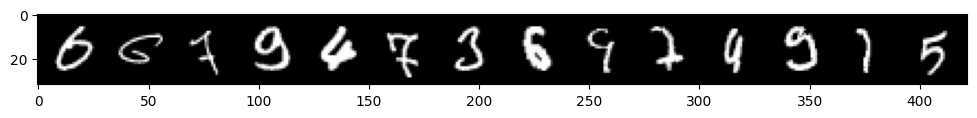

In [112]:
nextrow = next(row)

print(f"Index: {nextrow}")

print("Label: ", y_test.index_select(0,torch.tensor(nextrow)).numpy())
print("Predicted: ", predicted.index_select(0,torch.tensor(nextrow)).numpy())


images = X_test.index_select(0,torch.tensor(nextrow))

from torchvision.utils import make_grid

im = make_grid(images, nrow=r)
plt.figure(figsize=(12,6))
plt.imshow(np.transpose(im.numpy(), (1,2,0)))


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()